In [1]:
import kagglehub

# Load the latest version
file_path = kagglehub.dataset_download(
  "amaymishra11/student-placement-and-salary-dataset-skills-based",
)

c:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 196k/196k [00:00<00:00, 300kB/s]

Extracting files...


### Reading Dataset

In [3]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv(os.path.join(file_path,"student_placement_salary_elite_v2.csv"))
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   str    
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   str    
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   int64  
 16 

In [5]:
df.isna().sum()

student_id                0
cgpa                      0
branch                    0
college_tier              0
python_skill              0
dsa_skill                 0
ml_skill                  0
web_dev_skill             0
coding_score              0
communication_score       0
aptitude_score            0
internships               0
projects                  0
backlogs                  0
resume_score              0
skill_score               0
placed                    0
company_type           1298
job_role               1298
salary_lpa                0
dtype: int64

In [8]:
print(df[df['job_role'].isna()]['placed'].unique())
print(df[df['company_type'].isna()]['placed'].unique())

[0]
[0]


In [9]:
df.describe()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.507213,2.011778,0.650111,0.555556,0.299778,0.393444,49.783567,6.991267,70.125711,1.032000,3.500556,0.421333,67.785989,1.898889,0.855778,55.409311
std,1.446496,0.818224,0.476961,0.496932,0.458186,0.488541,28.891340,1.717548,17.475032,0.966191,1.707595,0.747207,17.058188,0.953059,0.351334,27.673531
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,16.500000,0.000000,0.000000,0.000000
25%,6.257500,1.000000,0.000000,0.000000,0.000000,0.000000,24.900000,5.500000,54.800000,0.000000,2.000000,0.000000,55.900000,1.000000,1.000000,43.427500
50%,7.500000,2.000000,1.000000,1.000000,0.000000,0.000000,49.600000,7.000000,70.300000,1.000000,4.000000,0.000000,67.400000,2.000000,1.000000,60.100000
75%,8.750000,3.000000,1.000000,1.000000,1.000000,1.000000,74.625000,8.500000,85.400000,2.000000,5.000000,1.000000,79.000000,3.000000,1.000000,75.380000
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.000000,129.430000


In [29]:
df = df[df['job_role'].notna() & df['company_type'].notna()]
df = df.drop(columns=['placed'])
df.shape

(7702, 19)

In [11]:
df.describe()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000,7702.0,7702.000000
mean,7.564085,1.942223,0.678136,0.585692,0.323682,0.421709,52.242405,7.075604,70.674124,1.110101,3.623994,0.328356,70.549234,2.009218,1.0,64.747312
std,1.441550,0.812294,0.467222,0.492634,0.467911,0.493864,28.612821,1.711062,17.415651,0.976987,1.700962,0.644071,16.042757,0.926205,0.0,17.035688
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,20.100000,0.000000,1.0,32.830000
25%,6.330000,1.000000,0.000000,0.000000,0.000000,0.000000,28.100000,5.600000,55.500000,0.000000,2.000000,0.000000,59.500000,1.000000,1.0,49.020000
50%,7.590000,2.000000,1.000000,1.000000,0.000000,0.000000,53.100000,7.100000,71.100000,1.000000,4.000000,0.000000,69.900000,2.000000,1.0,65.870000
75%,8.820000,3.000000,1.000000,1.000000,1.000000,1.000000,77.100000,8.600000,85.900000,2.000000,5.000000,0.000000,81.200000,3.000000,1.0,77.482500
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.0,129.430000


### Data Exploration

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

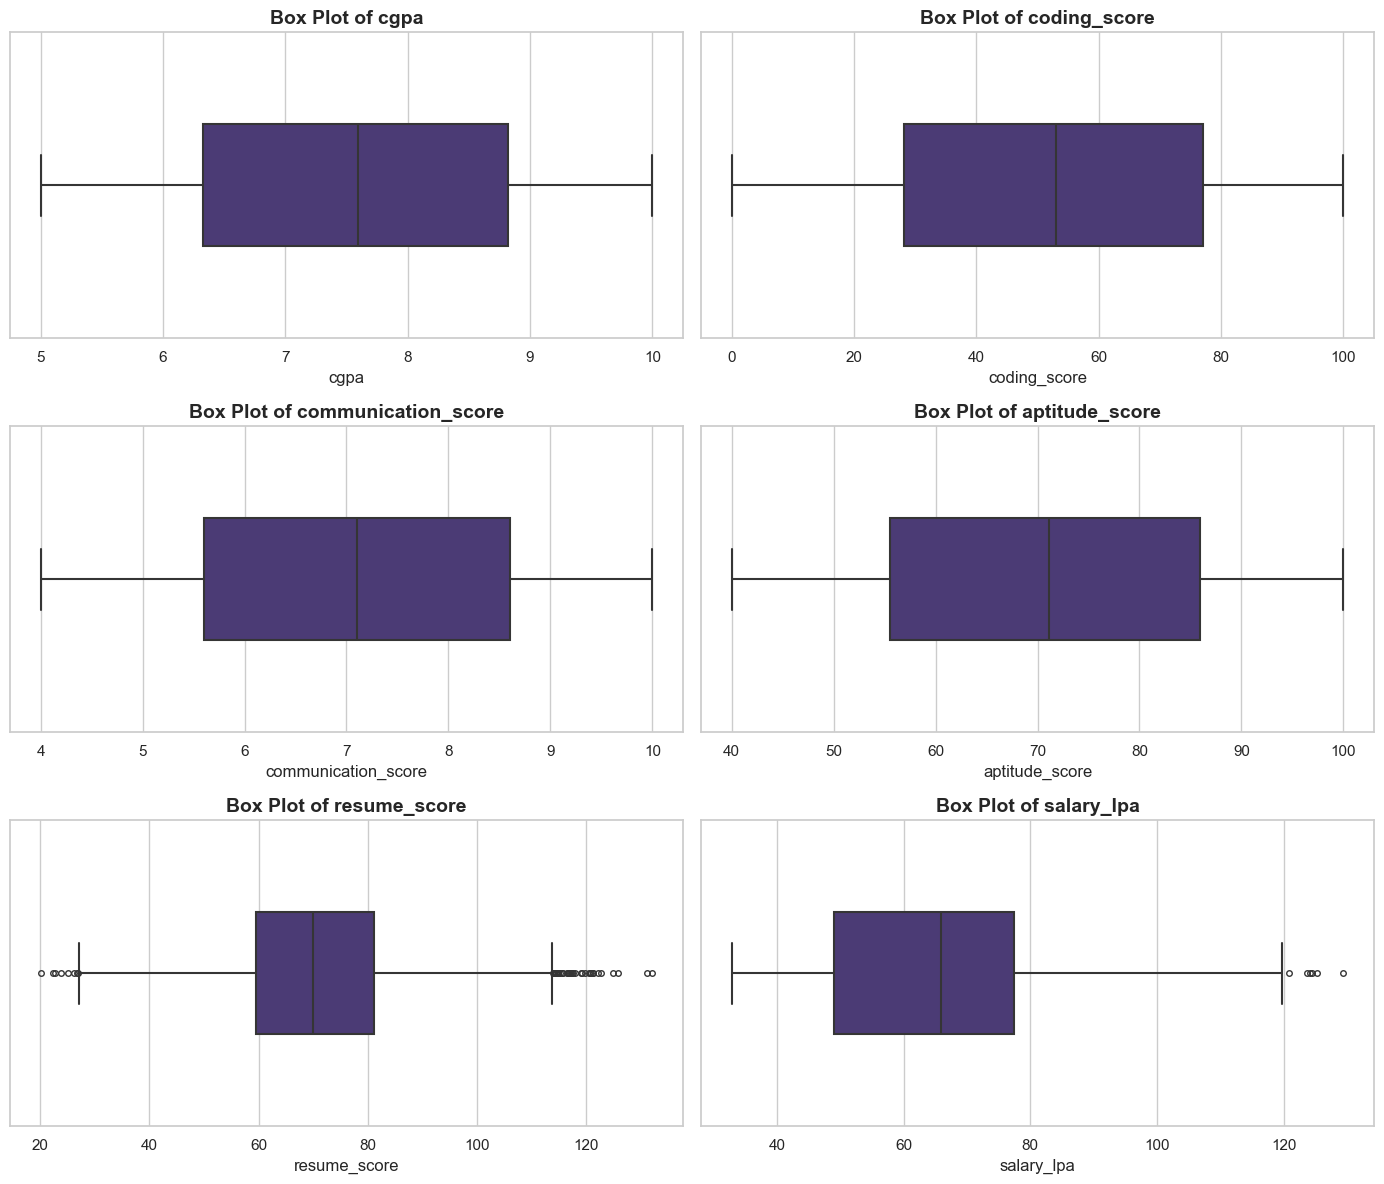

In [30]:
# Select numeric columns
num_cols = df.select_dtypes(include=['float64']).columns

# Set style
sns.set_theme(style="whitegrid", palette="viridis")

# Grid settings
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Handle case when only one column exists
if len(num_cols) == 1:
    axes = [axes]

# Plot boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(
        x=df[col],
        ax=ax,
        width=0.4,
        fliersize=4,
        linewidth=1.5
    )
    
    ax.set_title(f"Box Plot of {col}", fontsize=14, weight='bold')
    ax.set_xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

In [31]:
df[df["salary_lpa"]>120]

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,company_type,job_role,salary_lpa
948,S948,7.83,Mechanical,1,1,1,1,1,81.3,7.9,67.5,2,5,1,104.1,4,Top Tech,Web Developer,124.47
1441,S1441,8.05,EEE,1,1,1,1,1,98.1,9.9,86.3,3,2,0,108.3,4,Top Tech,Analyst,129.43
4015,S4015,5.12,Civil,1,1,1,1,1,79.7,9.2,68.6,2,1,1,89.2,4,Top Tech,Software Engineer,120.89
4206,S4206,9.35,CSE,1,1,1,0,1,93.4,8.7,44.1,1,1,0,68.2,3,Top Tech,Data Scientist,123.71
4738,S4738,8.70,Civil,1,1,1,1,1,86.2,5.8,53.5,2,5,0,101.5,4,Top Tech,Software Engineer,125.23
5626,S5626,9.96,Mechanical,1,1,1,1,0,78.7,7.6,97.7,2,6,0,99.8,3,Top Tech,Web Developer,124.13


In [32]:
df[df["resume_score"]>115]

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,company_type,job_role,salary_lpa
1503,S1503,9.96,Civil,1,1,1,1,1,42.4,7.8,68.8,2,6,1,116.6,4,Mid-size,Software Engineer,66.38
1807,S1807,8.77,IT,3,1,1,1,1,66.9,9.6,64.3,2,6,2,122.1,4,MNC,Web Developer,84.61
1910,S1910,5.38,IT,2,1,1,1,1,51.8,7.7,97.0,3,5,1,120.6,4,Mid-size,Web Developer,56.39
2027,S2027,6.42,ECE,1,0,1,1,1,70.6,7.9,95.4,3,6,0,117.0,3,MNC,Data Scientist,91.72
2488,S2488,9.50,ECE,3,1,1,1,1,38.5,9.6,43.3,2,6,0,120.5,4,MNC,Software Engineer,97.84
2512,S2512,6.28,CSE,1,1,1,0,1,26.3,9.7,40.8,3,6,1,117.5,3,Mid-size,Web Developer,63.13
2643,S2643,6.83,Civil,2,1,1,1,1,68.8,9.5,82.9,3,3,0,116.5,4,MNC,Software Engineer,85.94
2821,S2821,8.04,Mechanical,2,1,1,1,1,2.9,9.7,91.7,3,6,0,131.1,4,Mid-size,Analyst,66.56
2927,S2927,7.44,Civil,1,1,1,0,1,9.1,9.2,80.8,3,6,0,117.2,3,MNC,Web Developer,83.94
3387,S3387,6.61,Mechanical,2,1,1,1,1,59.4,5.4,60.0,3,6,0,119.0,4,Mid-size,Analyst,56.18


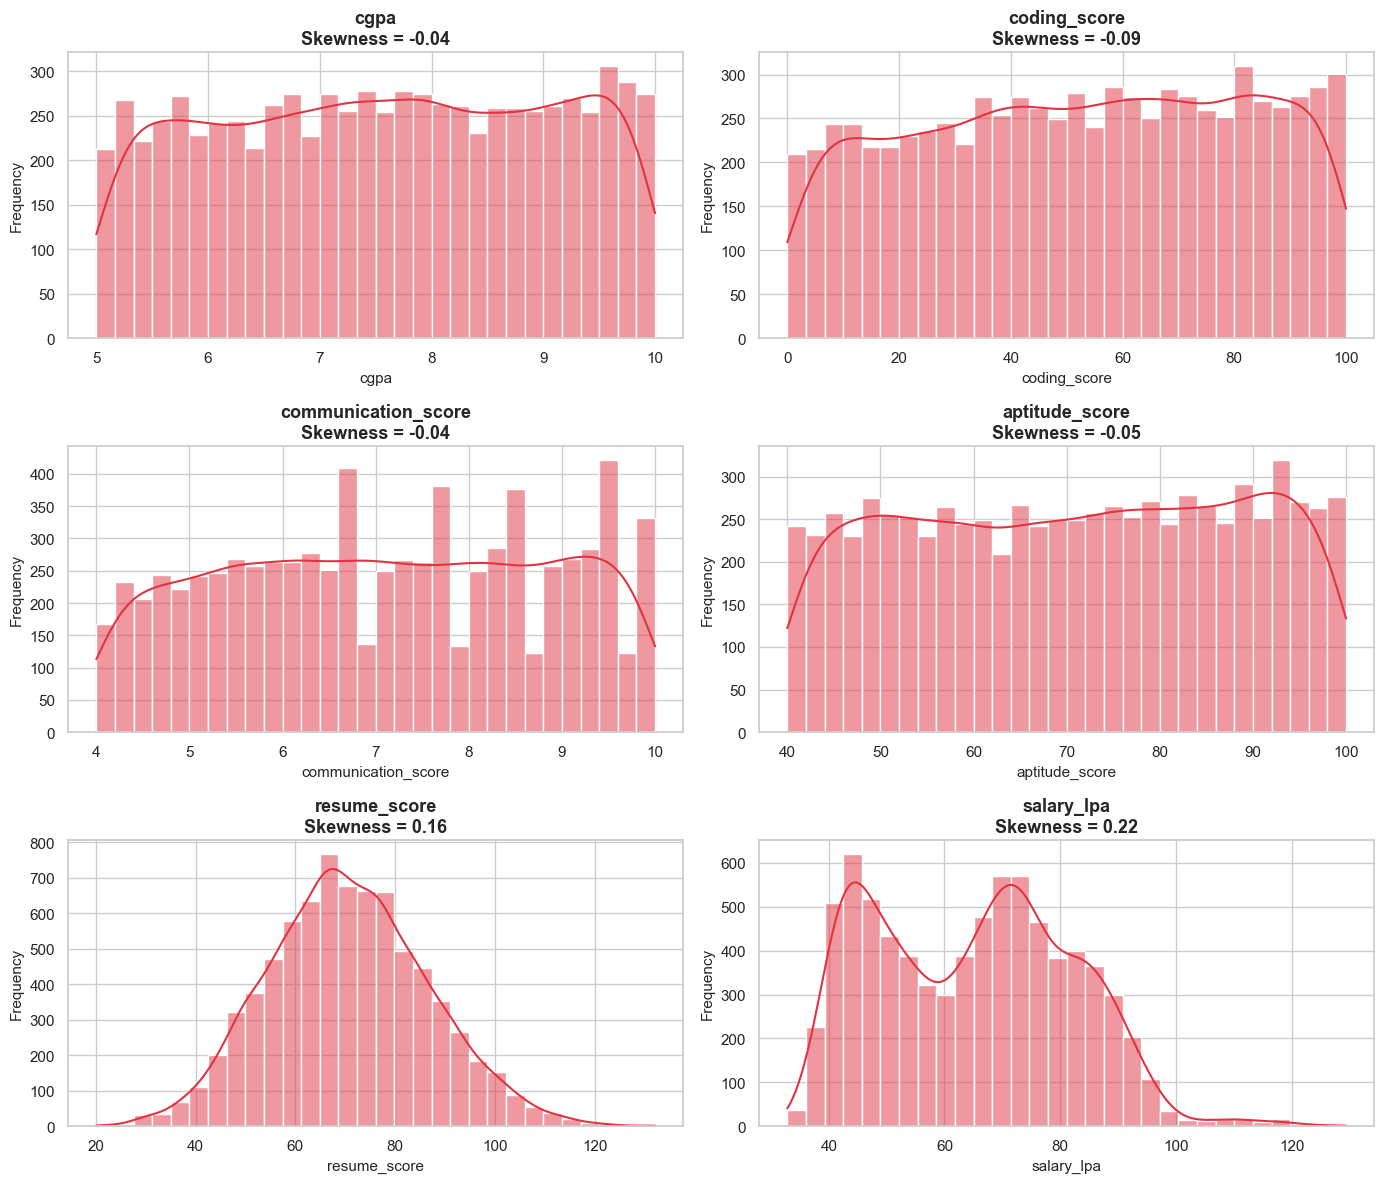

In [33]:
# Select numeric columns
num_cols = df.select_dtypes(include=['float64']).columns

# Set style
sns.set_theme(style="whitegrid", palette="crest")

# Grid settings
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Plot line charts
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=ax,
        color=sns.color_palette("rocket")[3]
    )

    skewness = np.round(df[col].skew(), 2)

    ax.set_title(
        f"{col}\nSkewness = {skewness}",
        fontsize=13,
        weight='bold'
    )

    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)

# Remove empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

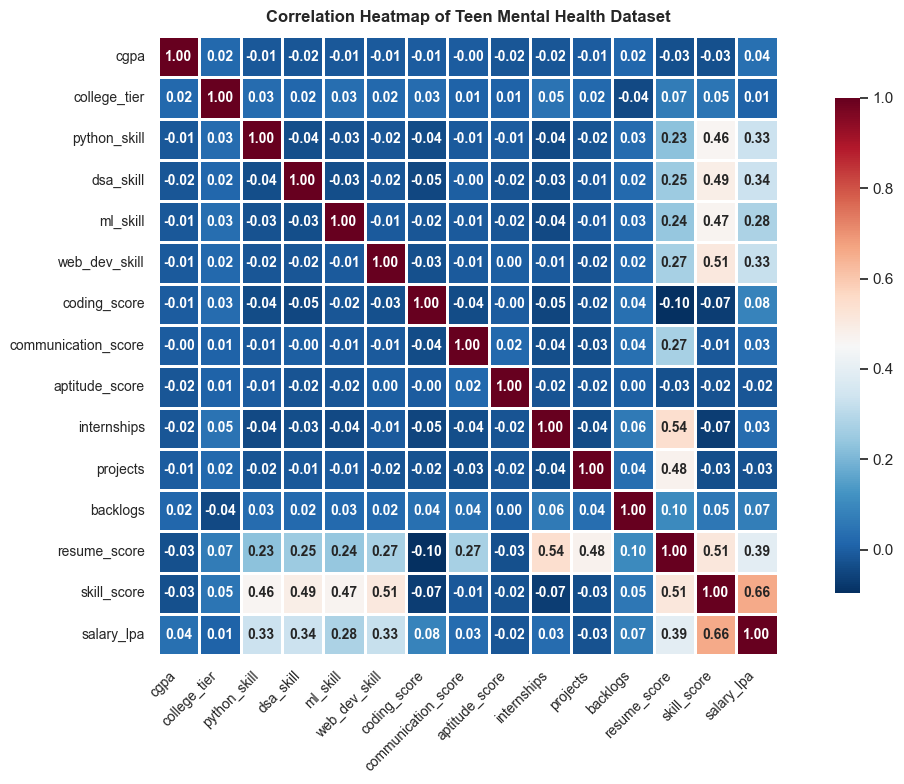

In [34]:
# Select numeric columns
columns_to_check = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df[columns_to_check].corr()

# Set theme
sns.set_theme(style="white")

# Create figure
plt.figure(figsize=(12, 8))

# Draw heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10, "weight": "bold"}
)

# Titles
plt.title(
    "Correlation Heatmap of Teen Mental Health Dataset",
    fontsize=12,
    weight='bold',
    pad=10
)

# Rotate labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Tight layout
plt.tight_layout()

plt.show()

In [44]:
columns_with_low_corr = ["cgpa", "college_tier", "coding_score", "aptitude_score", "backlogs"]
df = df.drop(columns=columns_with_low_corr)

In [144]:
def generate__barplot(df, x_col, y_col, hue_col=None, title="", xlabel="", ylabel="", legend_title="", figsize=(8, 4)):
    # Set style
    sns.set_theme(style="whitegrid", palette="Set2")


    plt.figure(figsize=figsize)
    
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        errorbar=None
    )
    
    # Add labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    
    # Titles and labels
    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    if hue_col:
        plt.legend(title=legend_title, bbox_to_anchor=(0.47, -0.2),loc='upper center', ncol=8)
    
    plt.tight_layout()
    plt.show()

In [150]:
def generate__countplot(df, x_col, hue_col=None, title="", xlabel="", ylabel="Count", legend_title="", figsize=(8, 4)):
    # Set style
    sns.set_theme(style="whitegrid", palette="Set2")

    plt.figure(figsize=figsize)
    
    ax = sns.countplot(
        data=df,
        x=x_col,
        hue=hue_col
    )
    
    # Add labels on bars
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    
    # Titles and labels
    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    if hue_col:
        plt.legend(title=legend_title, bbox_to_anchor=(0.47, -0.2),loc='upper center', ncol=8)
    
    plt.tight_layout()
    plt.show()

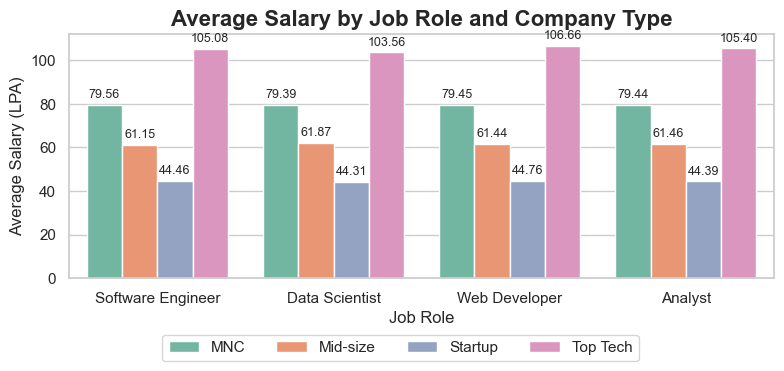

In [145]:
generate__barplot(
    df=df,
    x_col="job_role",
    y_col="salary_lpa",
    hue_col="company_type",
    title="Average Salary by Job Role and Company Type",
    xlabel="Job Role",
    ylabel="Average Salary (LPA)",
)

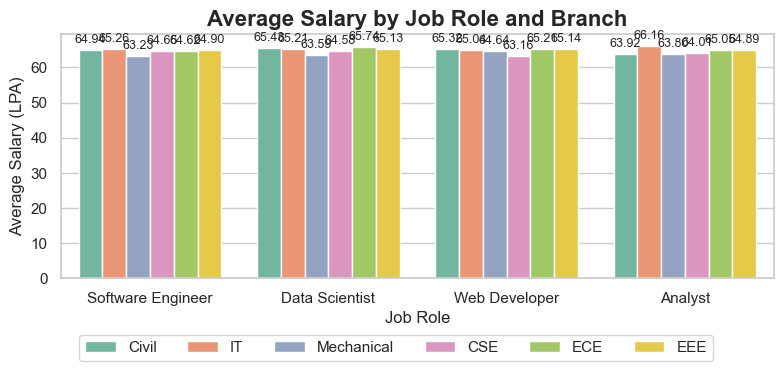

In [146]:
generate__barplot(
    df=df,
    x_col="job_role",
    y_col="salary_lpa",
    hue_col="branch",
    title="Average Salary by Job Role and Branch",
    xlabel="Job Role",
    ylabel="Average Salary (LPA)",
)

In [147]:
# Skill columns
skill_cols = ['python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill']

# Create skill combination label
df['skill_combination'] = df[skill_cols].apply(
    lambda row: ' + '.join(
        [col.replace('_skill', '').upper() for col, val in row.items() if val > 0]
    ) if row.sum() > 0 else 'No Skills',
    axis=1
)

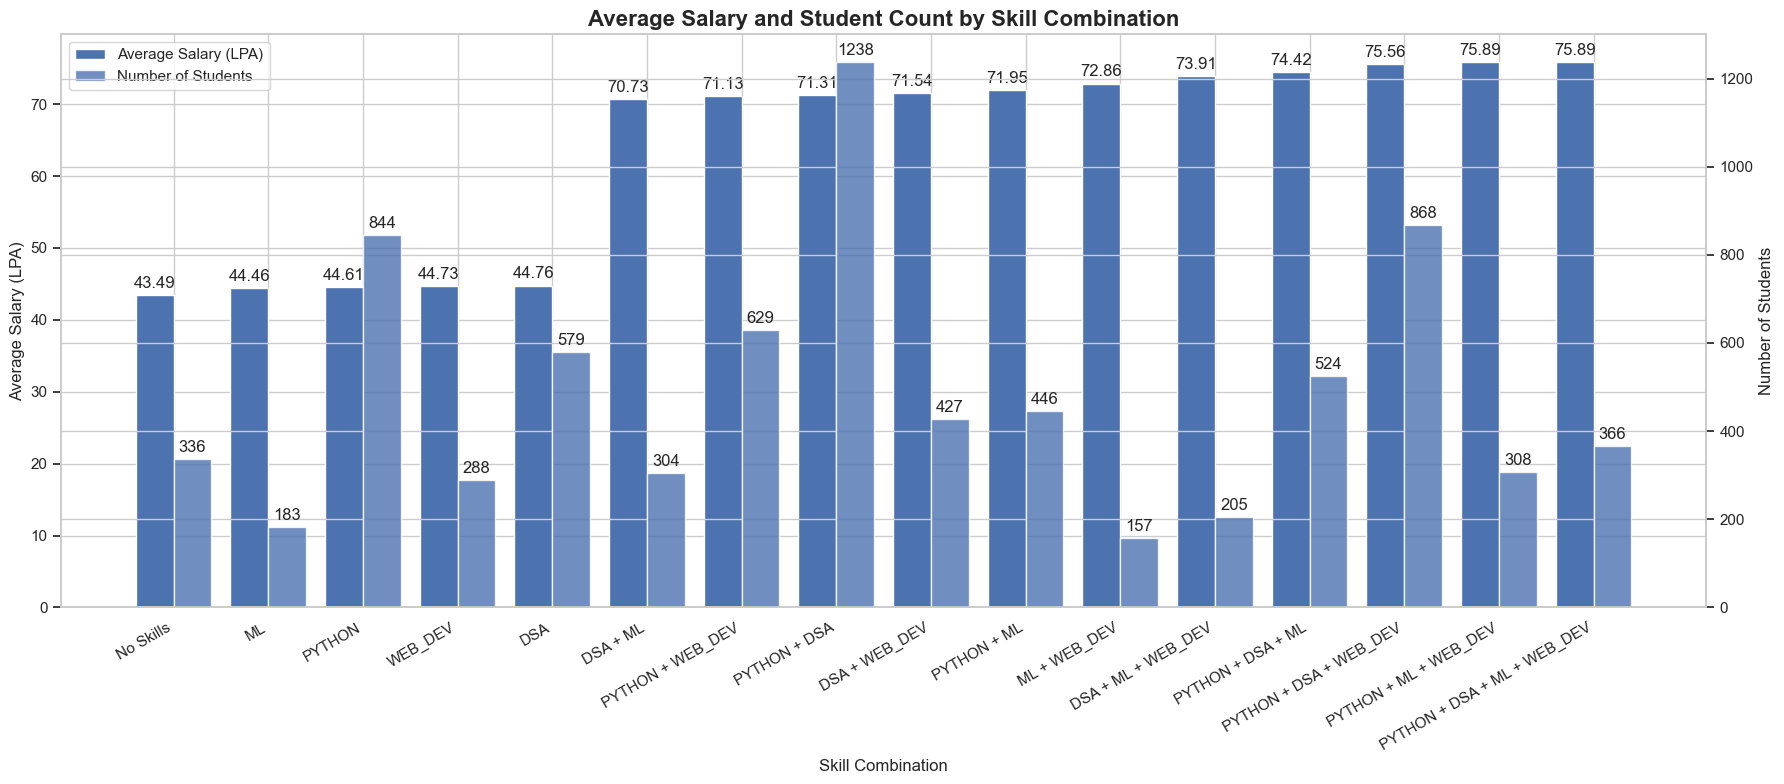

In [ ]:
# Aggregate data
summary_df = (
    df.groupby('skill_combination')
    .agg(
        avg_salary=('salary_lpa', 'mean'),
        student_count=('salary_lpa', 'size')
    )
    .sort_values('avg_salary')
    .reset_index()
)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
fig, ax1 = plt.subplots(figsize=(18, 8))

x = np.arange(len(summary_df))
width = 0.4

# Salary bars
bars1 = ax1.bar(
    x - width/2,
    summary_df['avg_salary'],
    width,
    label='Average Salary (LPA)'
)

# Second axis
ax2 = ax1.twinx()

# Student count bars
bars2 = ax2.bar(
    x + width/2,
    summary_df['student_count'],
    width,
    label='Number of Students',
    alpha=0.8
)

# Labels on bars
ax1.bar_label(bars1, fmt='%.2f', padding=3, fontsize=12)
ax2.bar_label(bars2, padding=3, fontsize=12)

# Titles and labels
ax1.set_title(
    "Average Salary and Student Count by Skill Combination",
    fontsize=16,
    weight='bold'
)

ax1.set_xlabel("Skill Combination", fontsize=12)
ax1.set_ylabel("Average Salary (LPA)", fontsize=12)
ax2.set_ylabel("Number of Students", fontsize=12)

# X ticks
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['skill_combination'], rotation=30, ha='right')

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

plt.tight_layout()
plt.show()

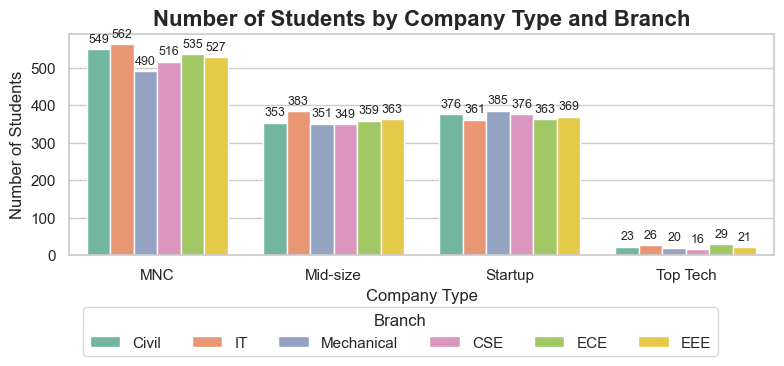

In [151]:
generate__countplot(
    df=df,
    x_col='company_type',
    hue_col='branch',
    title="Number of Students by Company Type and Branch",
    xlabel="Company Type",
    ylabel="Number of Students",
    legend_title="Branch"

)


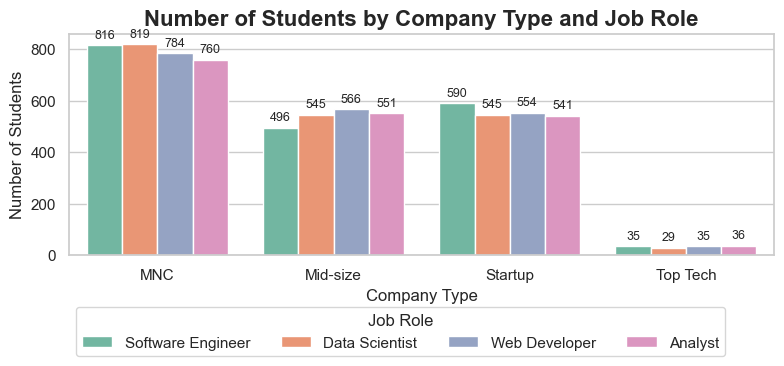

In [152]:
generate__countplot(
    df=df,
    x_col='company_type',
    hue_col='job_role',
    title="Number of Students by Company Type and Job Role",
    xlabel="Company Type",
    ylabel="Number of Students",
    legend_title="Job Role"
)

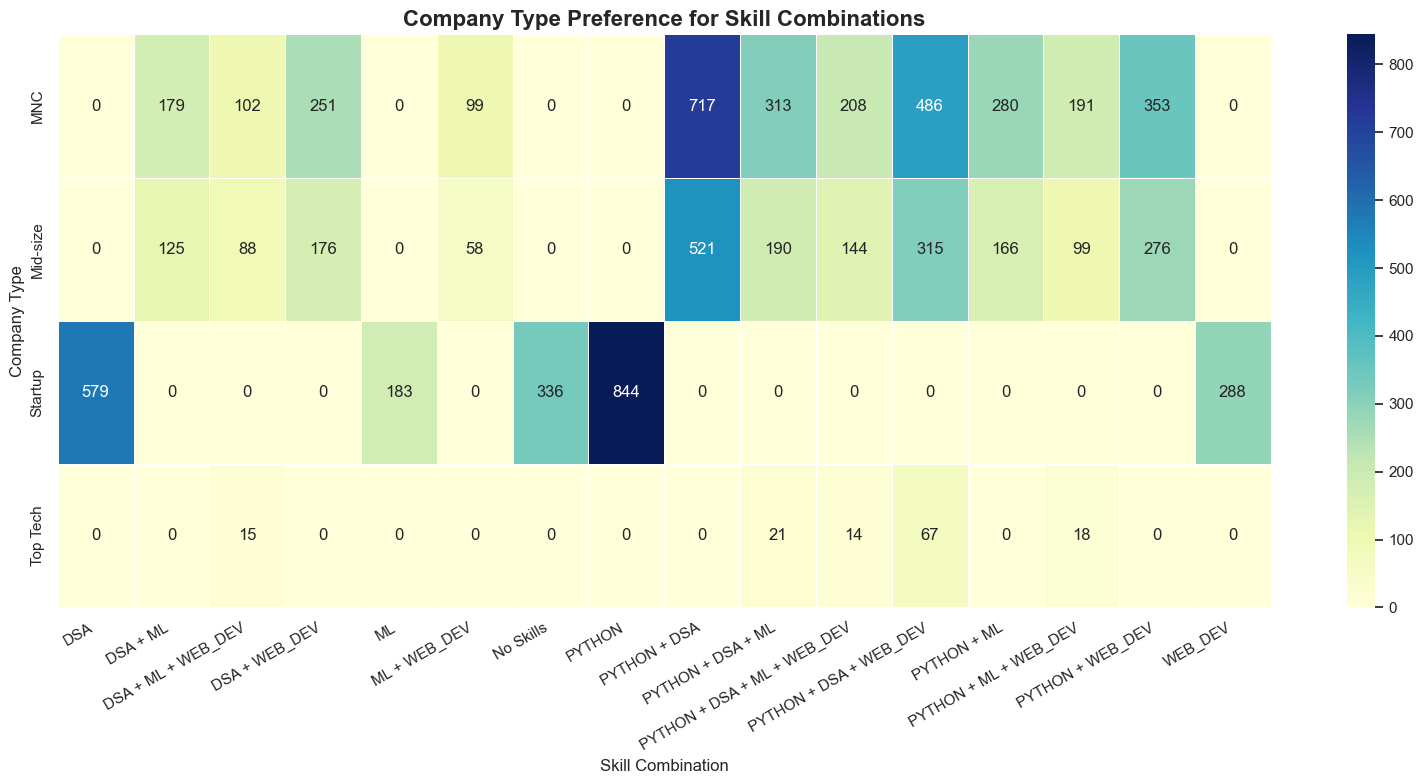

In [154]:
# Create frequency table
heatmap_data = pd.crosstab(
    df['company_type'],
    df['skill_combination']
)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(16, 8))

# Heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white'
)

# Titles and labels
plt.title(
    "Company Type Preference for Skill Combinations",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Skill Combination", fontsize=12)
plt.ylabel("Company Type", fontsize=12)

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

📌 Final Conclusion

The analysis of the student placement dataset reveals that traditional academic indicators such as backlogs, college tier, CGPA, communication score, and aptitude score show minimal influence on placement outcomes and salary trends. This suggests that modern recruitment, especially in the tech industry, is becoming increasingly skill-driven rather than purely academic-driven.

Among company categories, Top Tech companies offer the highest salary packages exceeding ₹100 LPA, followed by MNCs with packages around ₹80 LPA, mid-size companies with approximately ₹60 LPA, and startups offering close to ₹40 LPA. Interestingly, these salary ranges remain relatively consistent across different job roles such as Software Engineer, Data Scientist, Web Developer, and Analyst, indicating that company brand and scale have a stronger impact on compensation than the specific role itself.

The analysis also highlights the strong influence of technical skill combinations on salary growth. Individual skills such as Python, DSA, Machine Learning, and Web Development contribute to average salary packages in the range of ₹40–50 LPA. However, candidates possessing combinations of two or more complementary skills witness a significant salary boost, often reaching ₹70–80 LPA. This demonstrates that multidisciplinary technical expertise creates higher market value and improves employability.

In terms of recruitment volume, MNCs emerge as the largest recruiters with nearly 500 hires, followed by mid-size and startup companies with approximately 350–400 hires each. Top Tech companies, despite offering the highest salaries, maintain highly selective hiring practices with fewer than 30 recruits.

The hiring preference analysis further reveals distinct recruitment patterns across company types. MNCs and mid-size companies strongly prefer candidates skilled in Python + DSA, startups tend to favor candidates with strong Python expertise, while Top Tech companies seek highly versatile candidates with a combination of Python + DSA + Web Development skills.

Overall, the study clearly indicates that in today’s placement ecosystem, practical technical skills and diversified skill combinations outweigh traditional academic metrics. Students aiming for higher salary packages and better placement opportunities should focus on building strong, complementary technical skill sets rather than relying solely on academic performance. 🚀